# Import required libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import os
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import save_image
from tqdm import tqdm 
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

In [2]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Define the Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 8) # Bottleneck layer
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Use Sigmoid for final layer to get output in range [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def get_latent_vector(self, x):
        return self.encoder(x)


In [3]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128,  num_workers=8, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=128,  num_workers=8, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 264kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.29MB/s]


In [4]:
def save_latent_space(model, device, test_loader, path, num_batches=None, save=True):
    # Extract latent representations
    model.eval()
    os.makedirs(path, exist_ok=True)
    label_path = os.path.join(path, "labels.npy")
    latent_path = os.path.join(path, "latent_space.npy")
    
    with torch.no_grad():
        latent_space = []
        labels = []
        batch_count = 0  # Initialize batch counter
        
        for images, digit_labels in test_loader:
            if num_batches is not None and batch_count >= num_batches:
                break  # Stop if the specified number of batches is processed
                
            images = images.to(device)
            latents = model.get_latent_vector(images).cpu().numpy()
            latent_space.append(latents)
            labels.append(digit_labels.cpu().numpy())
            
            batch_count += 1  # Increment batch counter

        latent_space = np.concatenate(latent_space)
        labels = np.concatenate(labels)
        
        # Apply t-SNE to reduce dimensions to 2
        tsne = TSNE(n_components=2, perplexity=30, max_iter=300)
        pca = PCA(n_components=2)
        latent_2d = tsne.fit_transform(latent_space)
        # latent_2d = pca.fit_transform(latent_space)
        # Normalize latent_2D between 0 and 1 in each direction
        normalized_latent_2D = (latent_2d - np.min(latent_2d, axis=0)) / (np.max(latent_2d, axis=0) - np.min(latent_2d, axis=0))

        # Visualize the latent space
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(normalized_latent_2D[:, 0], normalized_latent_2D[:, 1], c=labels, cmap='tab10', alpha=0.6, edgecolor='k')
        plt.colorbar(scatter)
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.title('2D t-SNE Projection of Latent Space')
        plt.show()
        
        if(save):
            np.save(latent_path, latent_2d)
            np.save(label_path, labels)

Epoch [1/20], Loss: 0.0512


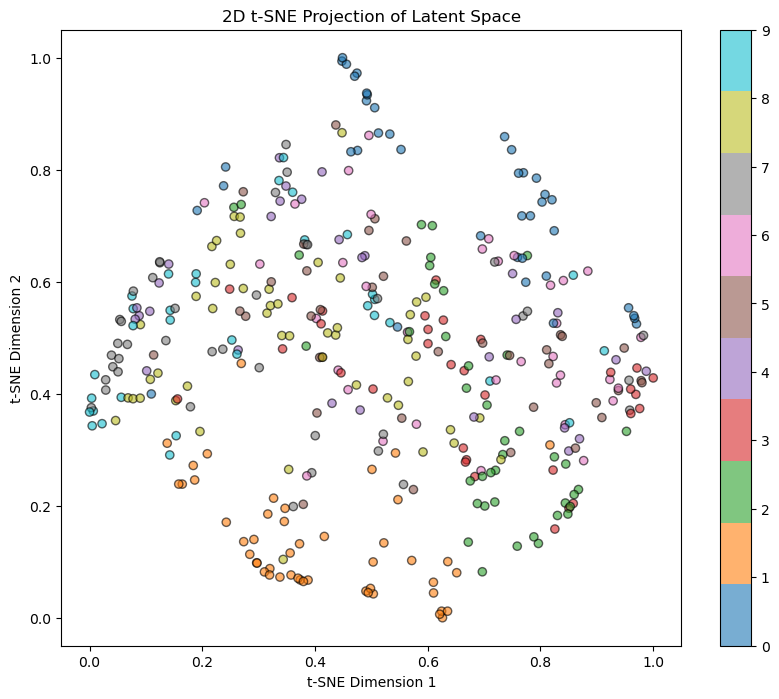

Epoch [2/20], Loss: 0.0420


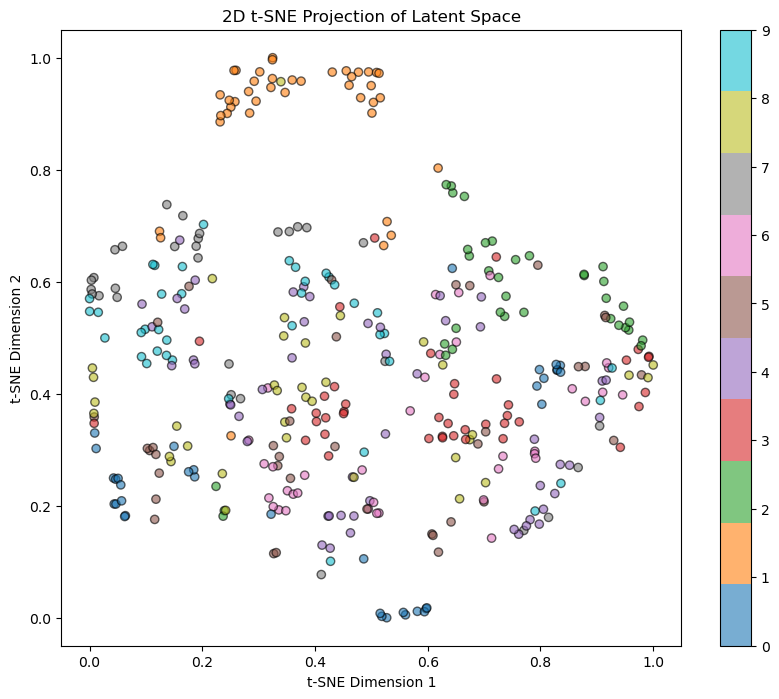

Epoch [3/20], Loss: 0.0366


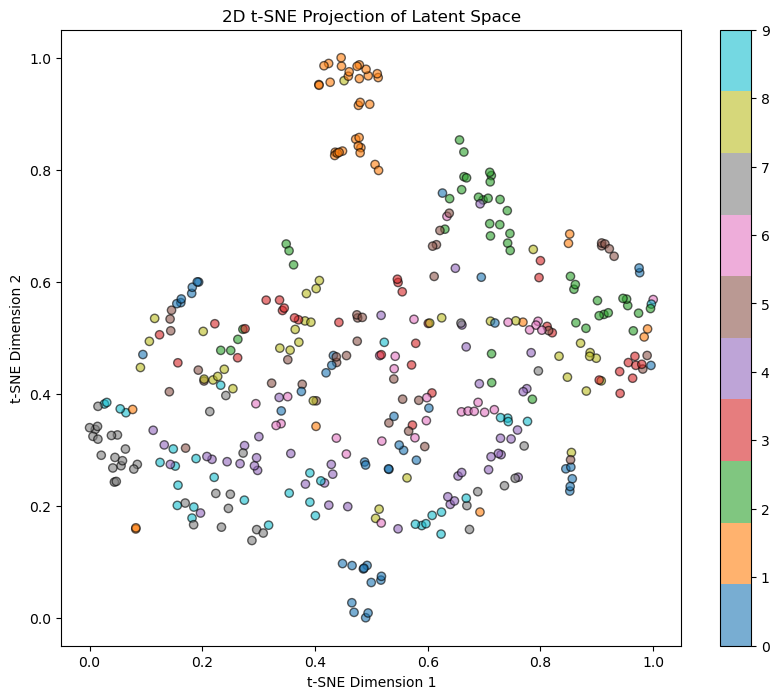

Epoch [4/20], Loss: 0.0312


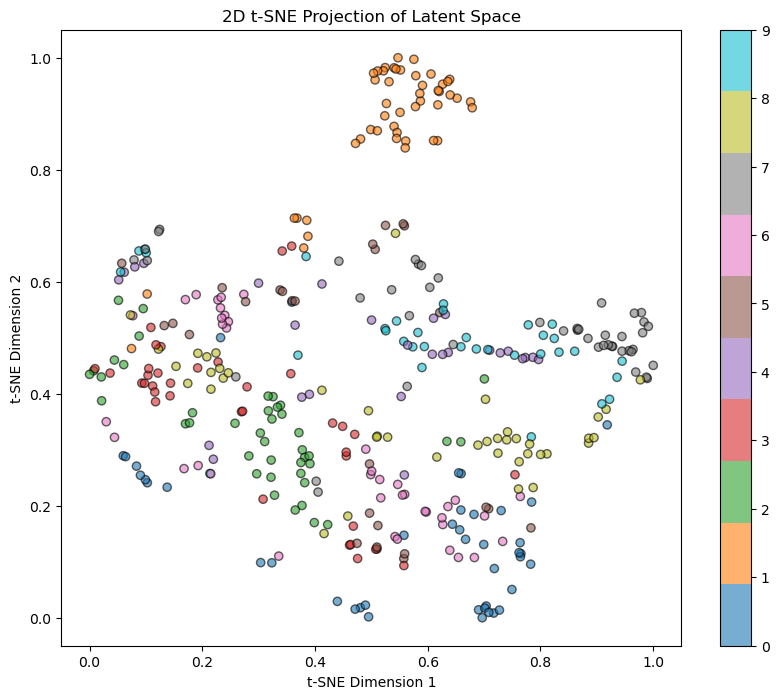

Epoch [5/20], Loss: 0.0303


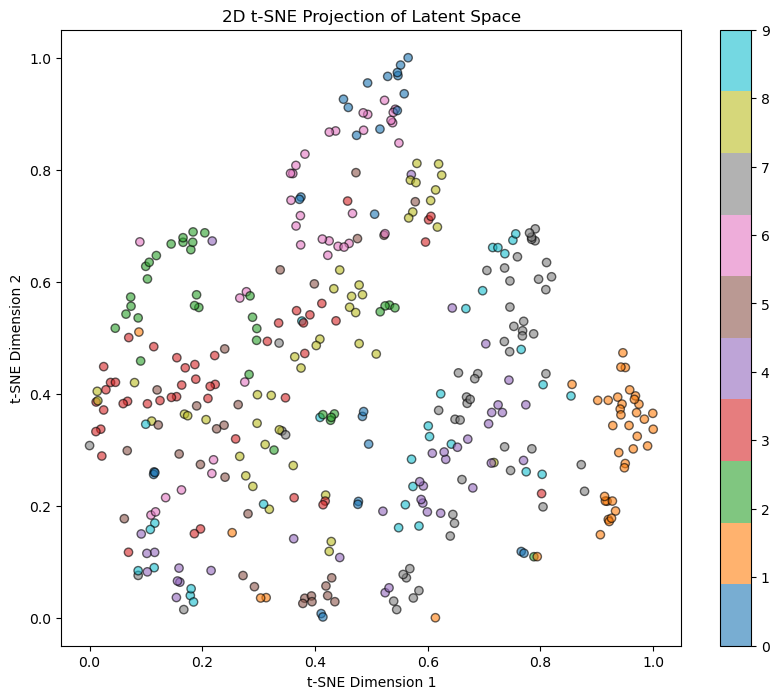

Epoch [6/20], Loss: 0.0299


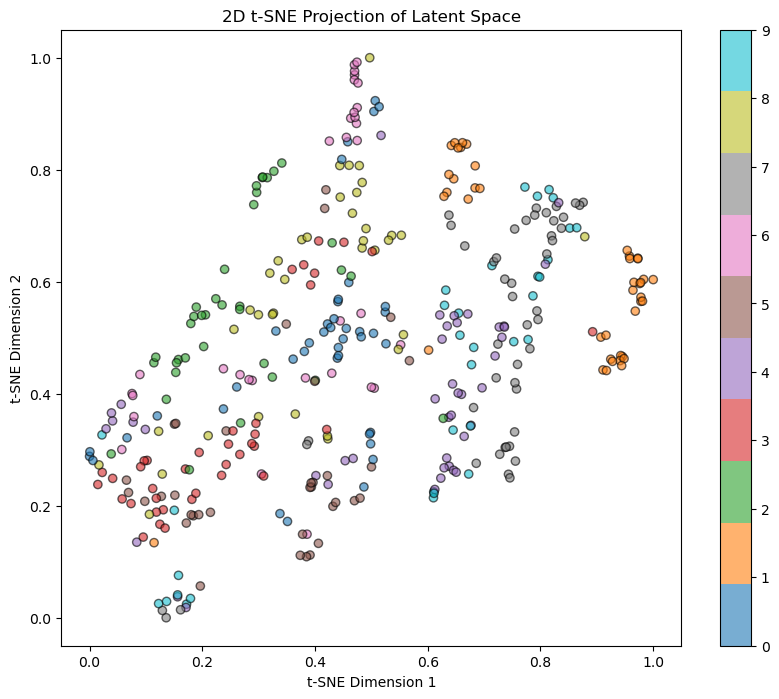

Epoch [7/20], Loss: 0.0270


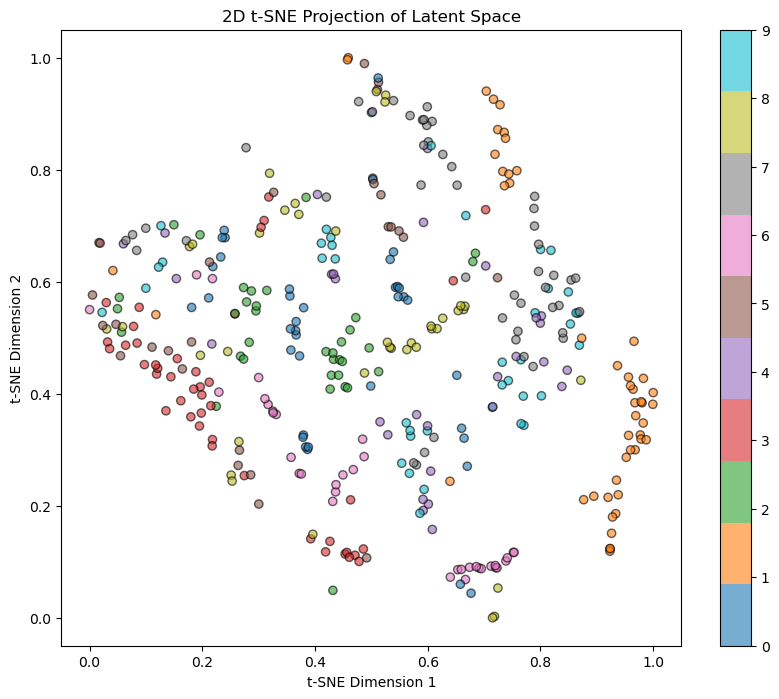

Epoch [8/20], Loss: 0.0246


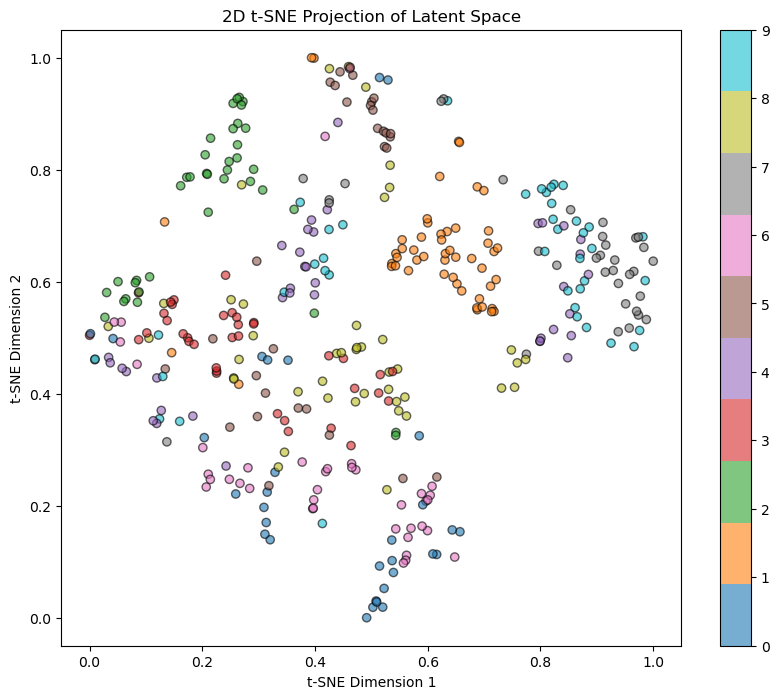

Epoch [9/20], Loss: 0.0282


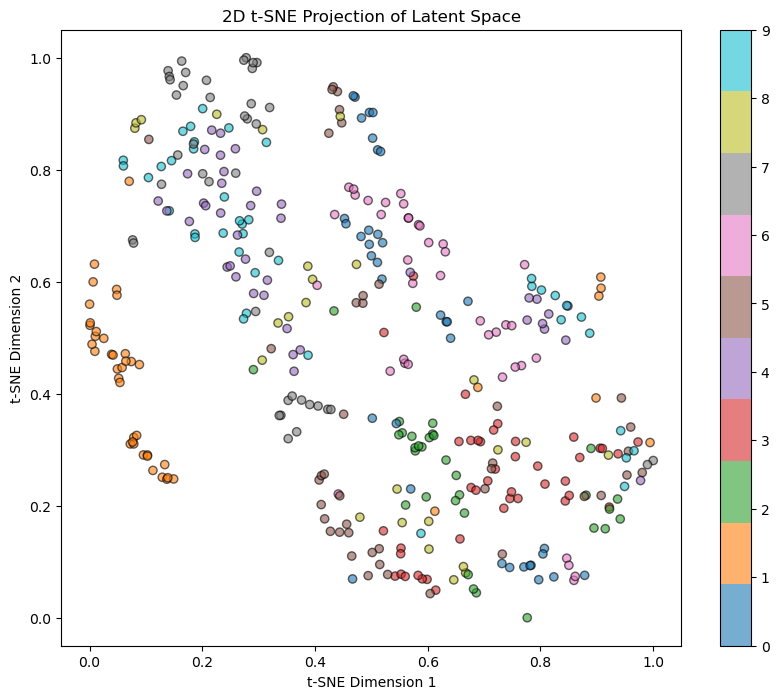

Epoch [10/20], Loss: 0.0248


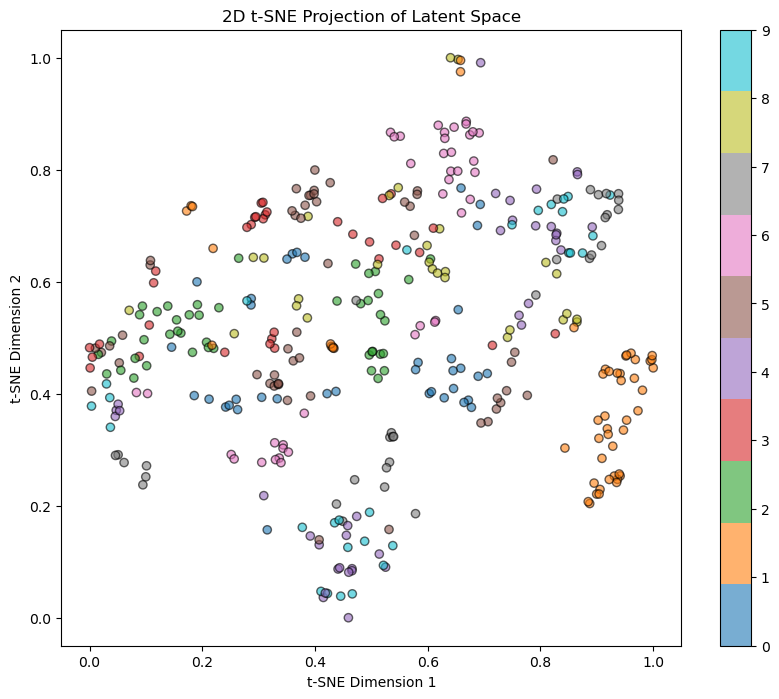

Epoch [11/20], Loss: 0.0248


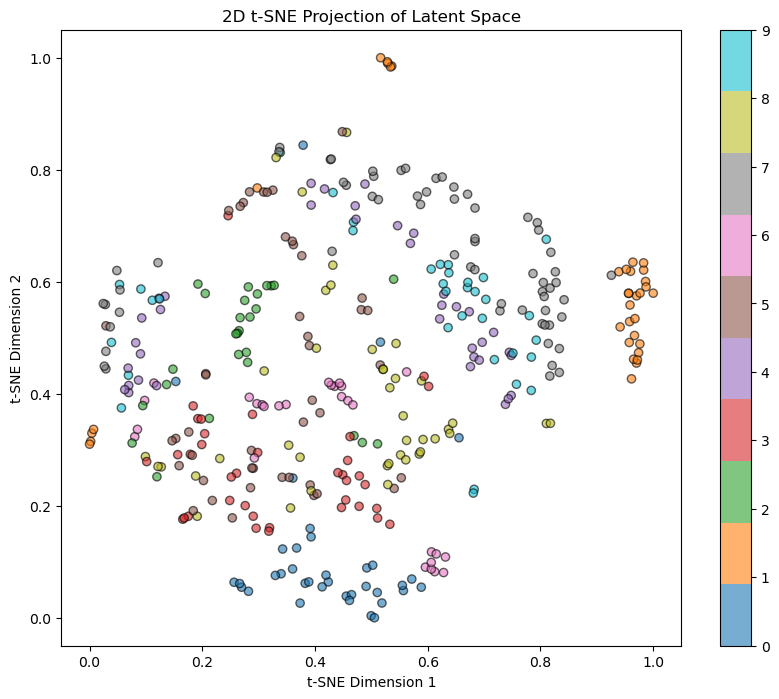

Epoch [12/20], Loss: 0.0242


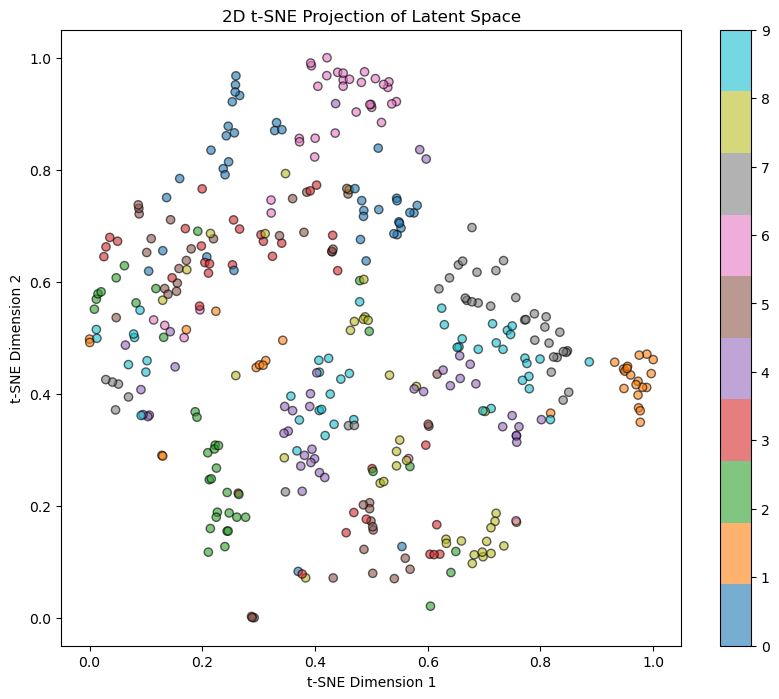

Epoch [13/20], Loss: 0.0245


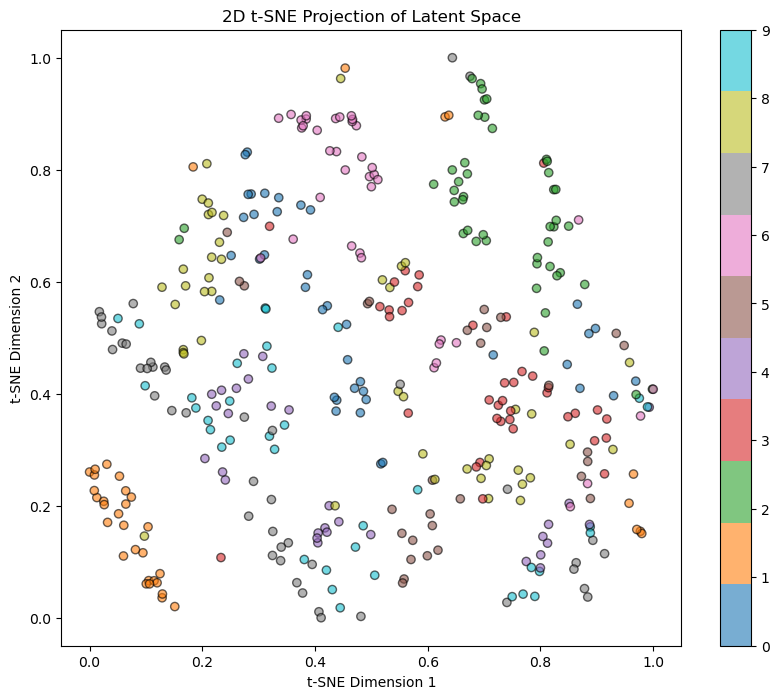

Epoch [14/20], Loss: 0.0271


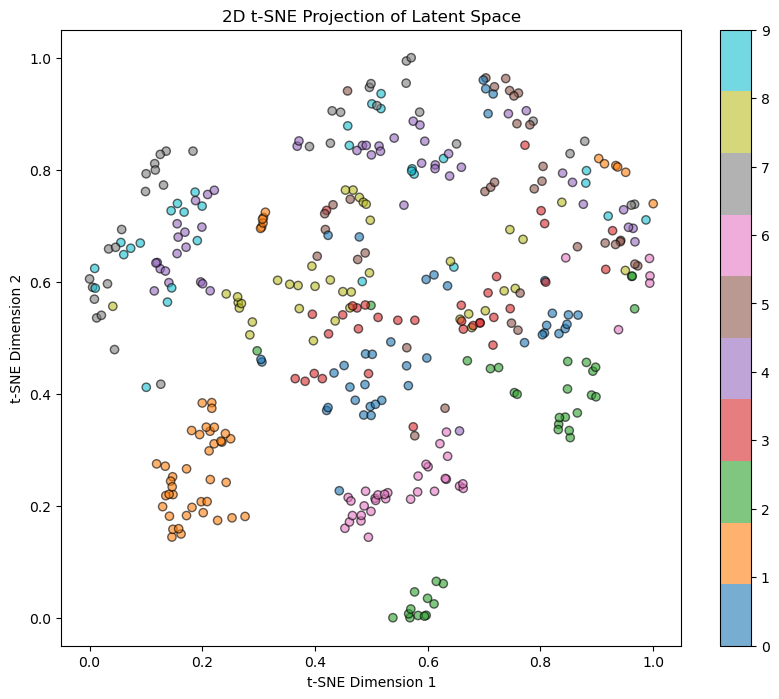

Epoch [15/20], Loss: 0.0240


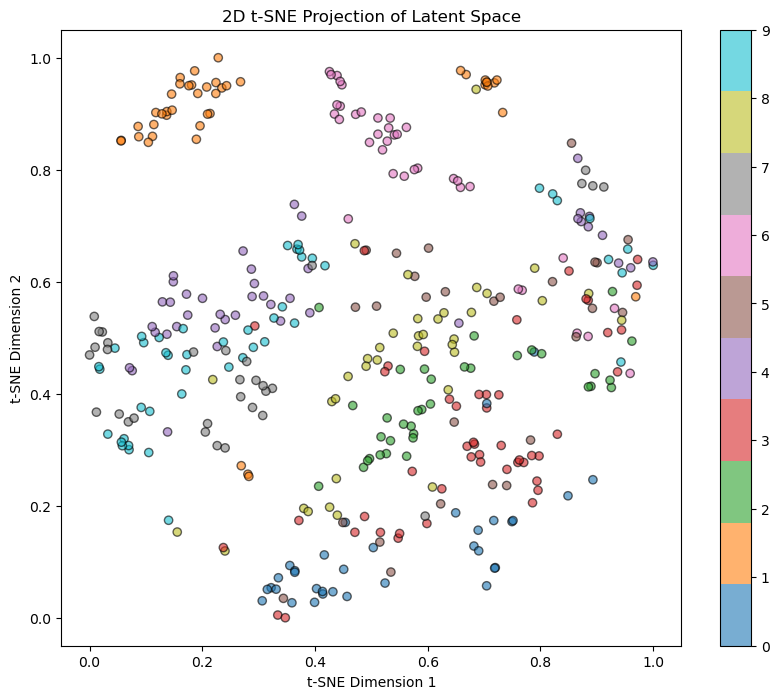

Epoch [16/20], Loss: 0.0219


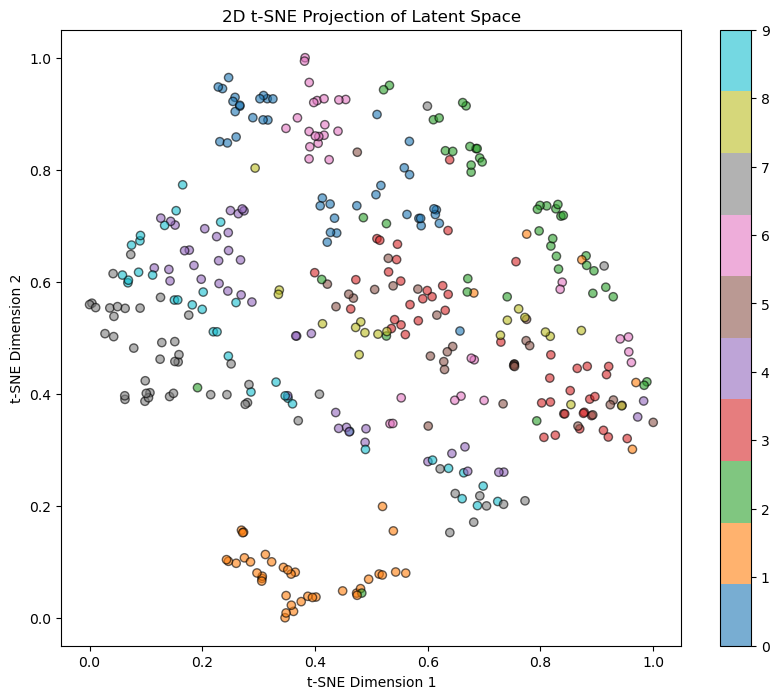

Epoch [17/20], Loss: 0.0225


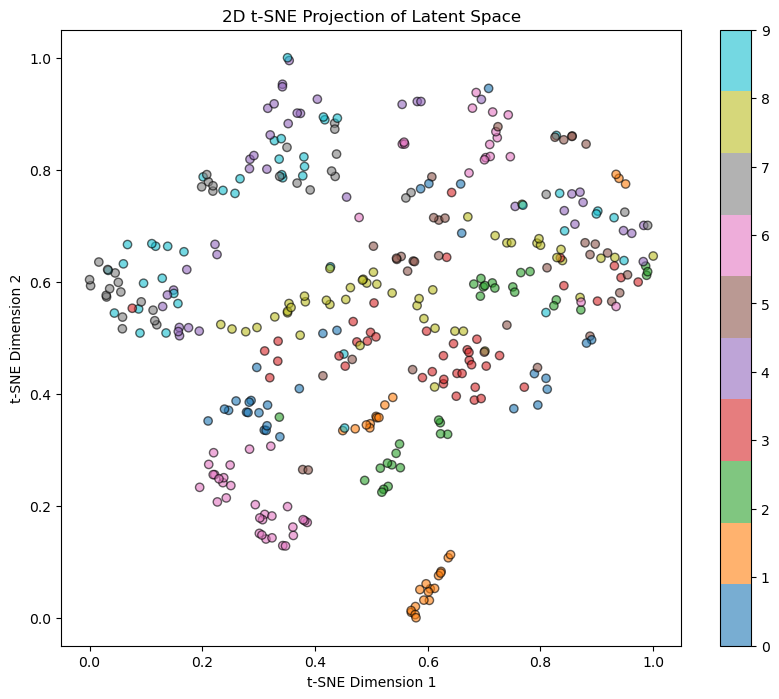

Epoch [18/20], Loss: 0.0216


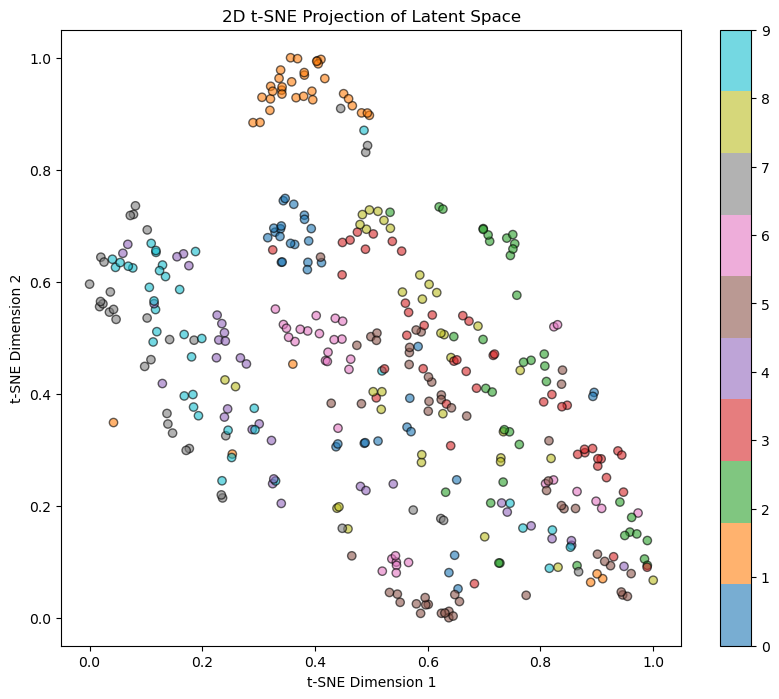

Epoch [19/20], Loss: 0.0205


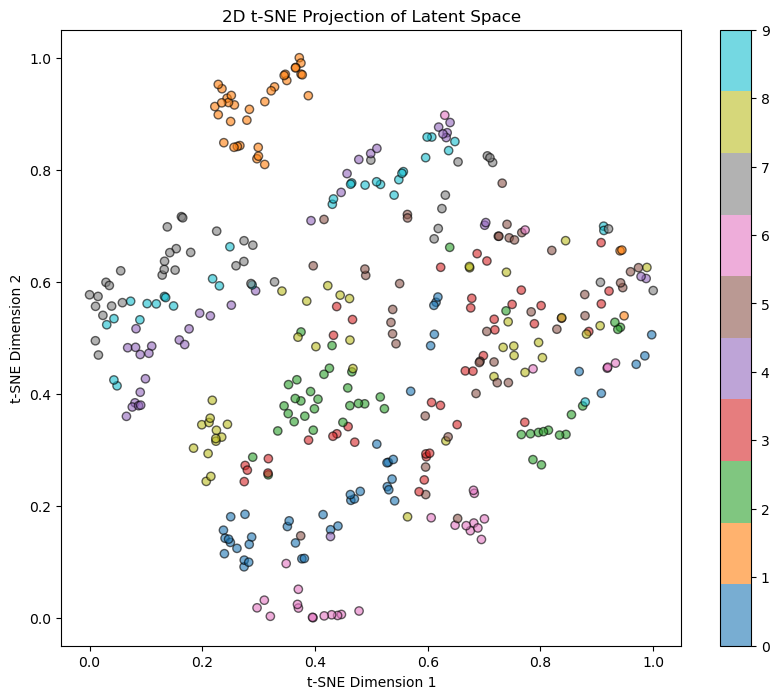

Epoch [20/20], Loss: 0.0208


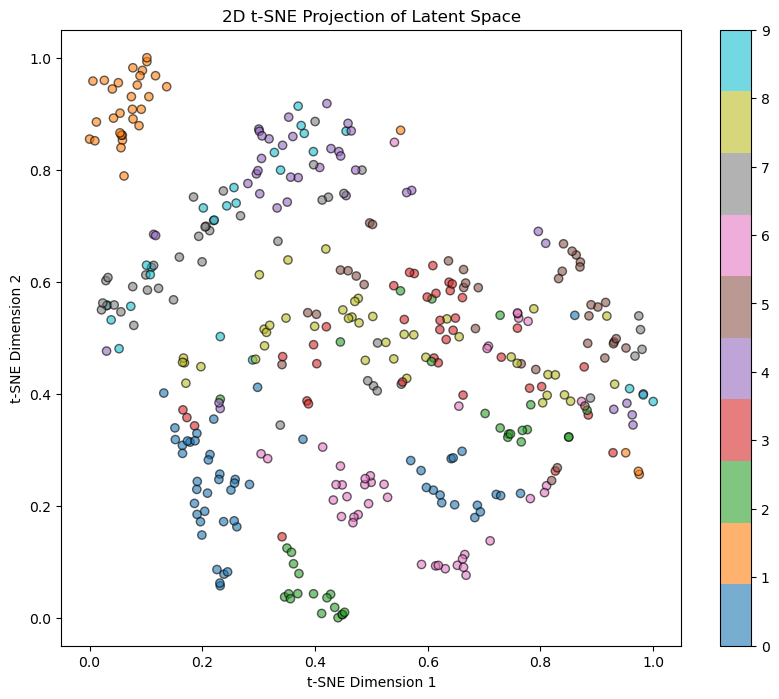

Training finished!


In [5]:
# Model, Loss Function, Optimizer
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    for idx, data in enumerate(train_loader):
        img, _ = data
        img = img.to(device)
        
        # Forward pass
        output = model(img)
        loss = criterion(output, img)
                
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    
    save_latent_space(model, device, train_loader, path=f'images/training/epoch_{epoch}/', num_batches=3)


print("Training finished!")

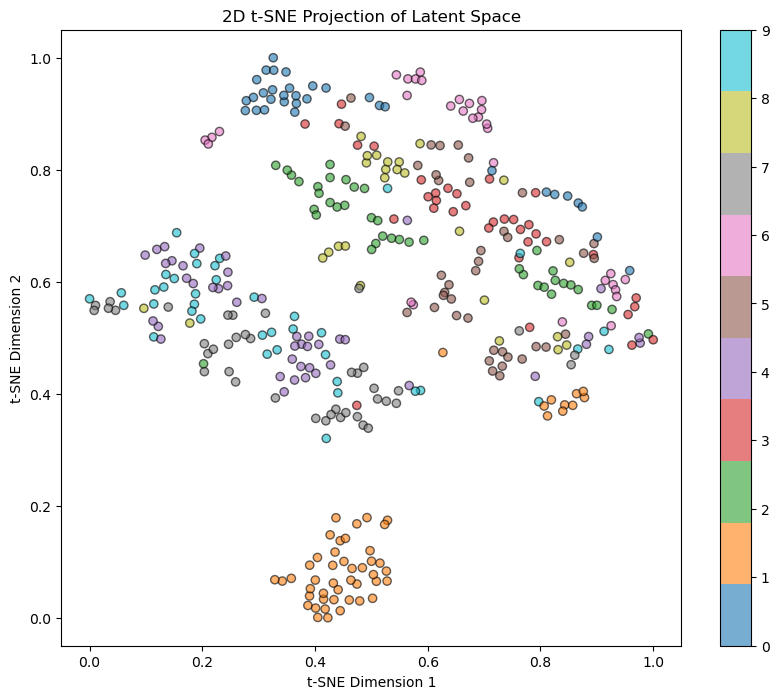

In [6]:
# Extract latent representations
model.eval()
num_batches = 3

with torch.no_grad():
    latent_space = []
    labels = []
    batch_count = 0  # Initialize batch counter
    
    for images, digit_labels in test_loader:
        if num_batches is not None and batch_count >= num_batches:
            break  # Stop if the specified number of batches is processed
            
        images = images.to(device)
        latents = model.get_latent_vector(images).cpu().numpy()
        latent_space.append(latents)
        labels.append(digit_labels.cpu().numpy())
        
        batch_count += 1  # Increment batch counter

    latent_space = np.concatenate(latent_space)
    labels = np.concatenate(labels)
    # latent_2d = latent_space # only if the bottleneck is 2D
    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, perplexity=20, max_iter=1000, learning_rate=50, random_state=42)
    latent_2d = tsne.fit_transform(latent_space) # we have to use t-SNE since the bottleneck is 8D
    normalized_latent_2D = (latent_2d - np.min(latent_2d, axis=0)) / (np.max(latent_2d, axis=0) - np.min(latent_2d, axis=0))

    # Visualize the latent space
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(normalized_latent_2D[:, 0], normalized_latent_2D[:, 1], c=labels, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.colorbar(scatter)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.title('2D t-SNE Projection of Latent Space')
    plt.show()

In [7]:
path = 'images/final_latent/'
os.makedirs(path, exist_ok=True)

label_path = os.path.join(path, "labels.npy")
latent_path = os.path.join(path, "latent_space.npy")
    
np.save(latent_path, normalized_latent_2D)
np.save(label_path, labels)

tensor([ 10.6464, -31.6980,   9.6260, -16.1094, -12.1862,  14.8366,  19.7768,
         -0.7429], device='cuda:0', grad_fn=<ViewBackward0>)


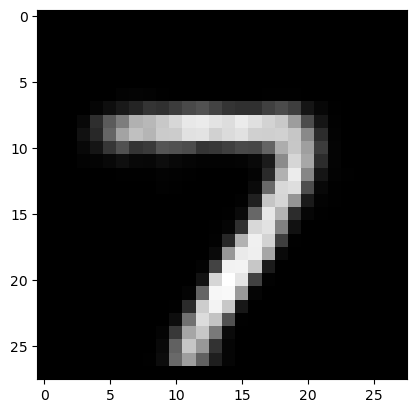

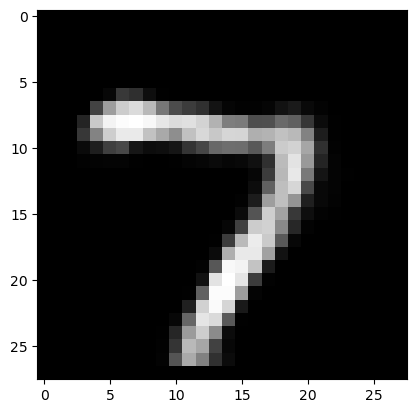

In [8]:
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
encoded = model.encoder(test_images[0])
print(encoded)

clean_decoded = model.decoder(encoded)
near_decoded = model.decoder(encoded + 1)
plt.imshow(clean_decoded.cpu().detach().numpy().reshape(28,28), cmap='gray')
plt.show()
plt.imshow(near_decoded.cpu().detach().numpy().reshape(28,28), cmap='gray')
plt.show()

In [9]:
latent_space_1 = np.load('images/training/epoch_0/latent_space.npy')
labels_1 = np.load('images/training/epoch_0/labels.npy')

print(f"Latent space shape: {latent_space_1.shape}")
print(f"Labels shape: {labels_1.shape}")

Latent space shape: (384, 2)
Labels shape: (384,)


In [10]:
latent_space_1 = np.load('images/training/epoch_0/latent_space.npy')
labels_1 = np.load('images/training/epoch_0/labels.npy')

# The saved latent_space is 2D (after t-SNE reduction)
min_vals = [float('inf'), float('inf')]
max_vals = [float('-inf'), float('-inf')]

for i in range(0, 20):
    latent_space = np.load(f'images/training/epoch_{i}/latent_space.npy')
    
    # Get min/max for each dimension
    for dim in range(2):
        current_min = np.min(latent_space[:, dim])
        current_max = np.max(latent_space[:, dim])
        
        if current_min < min_vals[dim]:
            min_vals[dim] = current_min
        if current_max > max_vals[dim]:
            max_vals[dim] = current_max

print(f"Min values across all epochs: {min_vals}")
print(f"Max values across all epochs: {max_vals}")

Min values across all epochs: [-17.720259, -12.320763]
Max values across all epochs: [17.701187, 13.976129]


In [11]:

# Custom Dataset to filter for specific class
class FilteredMNIST(Dataset):
    def __init__(self, dataset, target_class):
        self.dataset = dataset
        self.target_class = target_class
        self.filtered_indices = [i for i, (img, label) in enumerate(dataset) if label == target_class]
        
    def __len__(self):
        return len(self.filtered_indices)
    
    def __getitem__(self, idx):
        img, label = self.dataset[self.filtered_indices[idx]]
        return img, label

# Create a DataLoader for class "1"
class_of_interest = 4
filtered_dataset = FilteredMNIST(test_dataset, class_of_interest)
filtered_loader = DataLoader(filtered_dataset, batch_size=64, shuffle=False)

# Initialize and load the autoencoder
autoencoder = Autoencoder().to(device)
# Here you should load your trained model if you have one
# For example: autoencoder.load_state_dict(torch.load('autoencoder.pth'))

# Encode the filtered images and get latent vectors
latent_vectors = []

# Put the autoencoder in evaluation mode
autoencoder.eval()

with torch.no_grad():  # No need to calculate gradients for encoding
    for data, _ in filtered_loader:
        data = data.to(device)
        latent_vector = autoencoder.get_latent_vector(data)
        latent_vectors.append(latent_vector.cpu().numpy())

# Create directory if it doesn't exist
save_path = 'images/samples/'
os.makedirs(save_path, exist_ok=True)
        
coordx = []
coordy = []

for i in range(5):
    data = filtered_dataset[i][0].to(device)
    plt.imsave(os.path.join(save_path, f'digit4_sample_{i}.png'), data.cpu().view(28, 28).numpy(), cmap='gray')
    coordx.append(autoencoder.get_latent_vector(data).cpu().detach().numpy()[0])
    coordy.append(autoencoder.get_latent_vector(data).cpu().detach().numpy()[1])
print(coordx)
print(coordy)

[0.01654604, 0.011239812, 0.01758723, 0.013928704, 0.0143149905]
[0.21738014, 0.22084045, 0.21431728, 0.2191017, 0.21862303]


In [ ]:
# Function to add noise to images
def add_noise(images, noise_factor=0.3):
    noisy_images = images + noise_factor * torch.randn(*images.shape, device=images.device)
    noisy_images = torch.clip(noisy_images, 0., 1.)
    return noisy_images

# Function to display images - 2 rows (original and reconstructed)
def show_images_2rows(original, reconstructed, n=10):
    plt.figure(figsize=(18, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title('Original')
        
        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title('Reconstructed')
    plt.show()

# Function to display images - 3 rows (original, noisy, reconstructed)
def show_images_3rows(original, noisy, reconstructed, n=10):
    plt.figure(figsize=(18, 6))
    for i in range(n):
        # Original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(original[i].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title('Original')
        
        # Noisy
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title('Noisy')
        
        # Reconstructed
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title('Reconstructed')
    plt.show()

# Get a batch of test images
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

# Reconstruct images
with torch.no_grad():
    reconstructed_images = model(test_images)

# Add noise to test images
noisy_images = add_noise(test_images)

# Reconstruct noisy images
with torch.no_grad():
    reconstructed_noisy_images = model(noisy_images)

# Convert images to numpy for visualization
test_images = test_images.cpu().numpy()
noisy_images = noisy_images.cpu().numpy()
reconstructed_images = reconstructed_images.cpu().numpy()
reconstructed_noisy_images = reconstructed_noisy_images.cpu().numpy()

# Display clean reconstruction (2 rows)
show_images_2rows(test_images, reconstructed_images, n=10)

# Display denoising reconstruction (3 rows)
show_images_3rows(test_images, noisy_images, reconstructed_noisy_images, n=10)

In [ ]:

import matplotlib.pyplot as plt

denoising_path = 'images/denoising/'
os.makedirs(denoising_path, exist_ok=True)

for i in range(4):  
    plt.imsave(os.path.join(denoising_path, f'clean_input_{i}.png'), test_images[i].reshape(28,28), cmap='gray')
    plt.imsave(os.path.join(denoising_path, f'noisy_input_{i}.png'), noisy_images[i].reshape(28,28), cmap='gray')
    plt.imsave(os.path.join(denoising_path, f'clean_reconstruction_{i}.png'), reconstructed_images[i].reshape(28,28), cmap='gray')
    plt.imsave(os.path.join(denoising_path, f'denoised_output_{i}.png'), reconstructed_noisy_images[i].reshape(28,28), cmap='gray')

# Homework

Create different autoencoders with varying latent dimensions and generate reconstructions for each of them

Tip: For the autoencoder class you just need to change the size of one layer of the encoder and one layer of the decoder.

Training 2D autoencoder...


Epoch [1/10], Loss: 0.2311
Epoch [2/10], Loss: 0.2312
Epoch [3/10], Loss: 0.2315
Epoch [4/10], Loss: 0.2319
Epoch [5/10], Loss: 0.2310
Epoch [6/10], Loss: 0.2319
Epoch [7/10], Loss: 0.2311
Epoch [8/10], Loss: 0.2320
Epoch [9/10], Loss: 0.2316
Epoch [10/10], Loss: 0.2309
Generated 2D images
Training 2D autoencoder...
Epoch [1/10], Loss: 0.0546
Epoch [2/10], Loss: 0.0499
Epoch [3/10], Loss: 0.0467
Epoch [4/10], Loss: 0.0428
Epoch [5/10], Loss: 0.0418
Epoch [6/10], Loss: 0.0421
Epoch [7/10], Loss: 0.0417
Epoch [8/10], Loss: 0.0423
Epoch [9/10], Loss: 0.0407
Epoch [10/10], Loss: 0.0370
Generated 2D images
Training 9D autoencoder...
Epoch [1/10], Loss: 0.0378
Epoch [2/10], Loss: 0.0309
Epoch [3/10], Loss: 0.0263
Epoch [4/10], Loss: 0.0237
Epoch [5/10], Loss: 0.0234
Epoch [6/10], Loss: 0.0211
Epoch [7/10], Loss: 0.0234
Epoch [8/10], Loss: 0.0203
Epoch [9/10], Loss: 0.0205
Epoch [10/10], Loss: 0.0202
Generated 9D images


# Homework 2

Generate latent space visualizations for 1 of the autoencoders trained in the previous points

In [ ]:
# model.eval() # change this to your model

# Uncomment this after changing your model above

# latent_2d_path = 'images/latent_2d/'
# os.makedirs(latent_2d_path, exist_ok=True)

# with torch.no_grad():
#     latent_space = []
#     labels = []
#     batch_count = 0
    
#     for images, digit_labels in test_loader:
#         if batch_count >= 3:  # Use 3 batches like the original code
#             break
            
#         images = images.to(device)
#         latents = model_2d.encoder(images).cpu().numpy()
#         latent_space.append(latents)
#         labels.append(digit_labels.cpu().numpy())
        
#         batch_count += 1

#     latent_space = np.concatenate(latent_space)
#     labels = np.concatenate(labels)
    
#     # Since it's already 2D, just normalize it
#     normalized_latent = (latent_space - np.min(latent_space, axis=0)) / (np.max(latent_space, axis=0) - np.min(latent_space, axis=0))
    
#     # Save
#     np.save(os.path.join(latent_2d_path, 'latent_space.npy'), normalized_latent)
#     np.save(os.path.join(latent_2d_path, 'labels.npy'), labels)
    
# print("Generated 2D latent space visualization")